<a href="https://colab.research.google.com/github/InahH-004/Parking-Space-Detection/blob/Inah/Tahap_1_Persiapan_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!kaggle --version

Kaggle CLI 2.0.2


#Import Dataset
Sumber dataset : https://www.kaggle.com/datasets/trainingdatapro/parking-space-detection-dataset

Path to dataset files: /kaggle/input/parking-space-detection-dataset

Path to Use : ./data

Note :    
- Dalam file annotation, anotasinya ditulis dengan nama 'polygon' bukan 'boxes'

In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("trainingdatapro/parking-space-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'parking-space-detection-dataset' dataset.
Path to dataset files: /kaggle/input/parking-space-detection-dataset


##Konfigurasi

In [14]:
import os

CONFIG = {
    "IMG_SIZE": (64, 64),
    "XML_PATH": os.path.join(path, "annotations.xml"),
    "IMAGES_DIR": os.path.join(path, "images"),
    "RANDOM_STATE": 42,
    "LABEL_MAP": {
        "free_parking_space": 0,
        "not_free_parking_space": 1,
        "partially_free_parking_space": 1
    }
}

# Verifikasi keberadaan file
assert os.path.exists(CONFIG["XML_PATH"]), "File annotations.xml tidak ditemukan!"
assert os.path.exists(CONFIG["IMAGES_DIR"]), "Direktori citra tidak ditemukan!"
print("Dataset siap digunakan di:", path)

Dataset siap digunakan di: /kaggle/input/parking-space-detection-dataset


In [15]:
!ls -l /kaggle/input/parking-space-detection-dataset

total 208
-rw-r--r-- 1 ubuntu ubuntu 204827 Sep 13 11:05 annotations.xml
drwxr-sr-x 2 ubuntu ubuntu      0 Sep 13 11:05 boxes
drwxr-sr-x 2 ubuntu ubuntu      0 Sep 13 11:05 images
-rw-r--r-- 1 ubuntu ubuntu    974 Sep 13 11:05 parking.csv


##File Check

In [16]:
import os
import xml.etree.ElementTree as ET

# Verifikasi keberadaan file utama
assert os.path.exists(CONFIG["XML_PATH"]), "File annotations.xml tidak ditemukan!"
assert os.path.exists(CONFIG["IMAGES_DIR"]), "Direktori citra tidak ditemukan!"

# Cek 1 sampel bounding box dari XML
tree = ET.parse(CONFIG["XML_PATH"])
root = tree.getroot()
first_image_node = root.find('image')

print(f"Sample Image Name : {first_image_node.get('name')}")
# Mengubah dari 'box' menjadi 'polygon' untuk mencocokkan struktur XML
print(f"Jumlah Anotasi Polygon: {len(first_image_node.findall('polygon'))}")
print("Lingkungan siap digunakan untuk modul pengerjaan.")

Sample Image Name : images/0.png
Jumlah Anotasi Polygon: 28
Lingkungan siap digunakan untuk modul pengerjaan.


#Ekstrak ROI
**Region Of Interst (ROI)** adalah area spesifik pada sebuah citra digital yang dipilih untuk diamati dan diproses lebih lanjut, yang dalam konteks proyek ini merujuk pada letak masing-masing petak slot parkir.

Tahap ini bergunakan untuk :    
1. **Fokus Pemrosesan Individual** : Proses ini memotong (crop) citra tempat parkir berskala penuh menjadi potongan-potongan gambar kecil (patches) berdasarkan koordinat batas area parkir yang tercatat di dalam file anotasi XML. Langkah ini memecah masalah besar menjadi tugas klasifikasi biner, sehingga model dapat menganalisis fitur secara terpusat pada setiap slot untuk menentukan apakah area tersebut berlabel 0 (kosong) atau 1 (terisi).
2. **Akurasi Terhadap Distorsi Kamera:** Penentuan koordinat peletakan ROI didasarkan pada referensi estimasi keberadaan mobil saat slot terpakai penuh, bukan mengacu pada garis pembatas parkir di aspal. Hal ini dilakukan karena acuan garis parkir tidak akan mampu melingkupi objek mobil dengan sempurna akibat dampak distorsi perspektif dari sudut pengambilan letak kamera pengawas.

**Hasil **

- Total gambar yang ditemukan dalam XML: 30
- Total gambar dengan setidaknya satu anotasi polygon: 30
- Total anotasi polygon di seluruh gambar: 903

Tersimpan di : ./data/processed

In [17]:
import os
import cv2
import xml.etree.ElementTree as ET
import numpy as np

# 1. Menyiapkan direktori penyimpanan berdasarkan label biner
# Tentukan direktori dasar tempat gambar yang diproses akan disimpan di lokasi yang dapat ditulisi
PROCESSED_DIR = "./data/processed"
os.makedirs(os.path.join(PROCESSED_DIR, "0"), exist_ok=True)
os.makedirs(os.path.join(PROCESSED_DIR, "1"), exist_ok=True)

# 2. Membaca struktur file anotasi XML
tree = ET.parse(CONFIG["XML_PATH"])
root = tree.getroot()

print("Memulai ekstraksi ROI petak parkir...")
total_extracted = 0

# 3. Iterasi untuk memproses setiap gambar yang tercatat di XML
for image_node in root.findall('image'):
    img_name = image_node.get('name')
    img_path = os.path.join(path, img_name)
    img = cv2.imread(img_path)

    # Lewati jika file gambar asli tidak ditemukan di direktori
    if img is None:
        # print(f"Peringatan: Gambar tidak ditemukan di {img_path}, melewati.")
        continue

    # 4. Iterasi setiap polygon di dalam gambar
    for idx, polygon_node in enumerate(image_node.findall('polygon')):
        label = polygon_node.get('label')

        # Konversi label teks menjadi angka (0 atau 1) menggunakan kontrak data
        num_label = CONFIG["LABEL_MAP"].get(label, 1)

        # Ambil titik koordinat polygon dari atribut 'points'
        points_str = polygon_node.get('points')

        # Parsing string points ke list of tuples (x, y)
        points = []
        for pair in points_str.split(';') : # Ubah pemisah dari spasi menjadi titik koma
            x, y = map(float, pair.split(','))
            points.append((int(x), int(y)))

        # Ubah points menjadi array numpy untuk cv2.boundingRect
        points_np = np.array(points)

        # Hitung bounding box (xtl, ytl, width, height) yang mengelilingi polygon
        xtl, ytl, width, height = cv2.boundingRect(points_np)
        xbr, ybr = xtl + width, ytl + height

        # Cegah eror dengan memastikan koordinat tidak melampaui batas dimensi gambar asli
        img_height, img_width = img.shape[:2]
        ytl, ybr = max(0, ytl), min(img_height, ybr)
        xtl, xbr = max(0, xtl), min(img_width, xbr)

        # 5. Lakukan pemotongan (cropping) citra
        patch = img[ytl:ybr, xtl:xbr]

        # Abaikan jika hasil crop kosong (koordinat tidak valid atau terlalu kecil)
        if patch.size == 0 or patch.shape[0] < 5 or patch.shape[1] < 5: # Tambahkan validasi ukuran minimum
            # print(f"Peringatan: Patch kosong atau terlalu kecil untuk {img_name}, polygon {idx}, melewati.")
            continue

        # 6. Simpan potongan gambar (patch) ke direktori kelas yang sesuai
        # Membersihkan nama file jika img_name memiliki format folder seperti 'images/0.png'
        clean_name = img_name.replace("/", "_").replace("\\", "_").split('.')[0]
        patch_filename = f"{clean_name}_patch_{idx}.jpg"
        save_path = os.path.join(PROCESSED_DIR, str(num_label), patch_filename) # Gunakan PROCESSED_DIR di sini

        cv2.imwrite(save_path, patch)
        total_extracted += 1

print(f"Proses selesai! Total {total_extracted} petak parkir berhasil diekstrak dan disimpan di {PROCESSED_DIR}.")

Memulai ekstraksi ROI petak parkir...
Proses selesai! Total 902 petak parkir berhasil diekstrak dan disimpan di ./data/processed.


In [18]:
!ls -l ./data/

total 8
drwxr-xr-x 4 root root 4096 Sep 13 11:05 processed
drwxr-xr-x 5 root root 4096 Sep 13 11:05 split


Mengecek total keseluruhan citra yang diperoleh dalam folder

In [19]:
import xml.etree.ElementTree as ET

# Membaca struktur file anotasi XML
tree = ET.parse(CONFIG["XML_PATH"])
root = tree.getroot()

total_images_with_boxes = 0
total_boxes_found = 0 # Mengganti nama variabel menjadi total_polygons_found untuk kejelasan

# Iterasi setiap gambar yang tercatat di XML
for image_node in root.findall('image'):
    # Mengubah dari 'box' menjadi 'polygon' untuk mencocokkan struktur XML
    polygons = image_node.findall('polygon')
    if len(polygons) > 0:
        total_images_with_boxes += 1
        total_boxes_found += len(polygons)

print(f"Total gambar yang ditemukan dalam XML: {len(root.findall('image'))}")
print(f"Total gambar dengan setidaknya satu anotasi polygon: {total_images_with_boxes}")
print(f"Total anotasi polygon di seluruh gambar: {total_boxes_found}")


Total gambar yang ditemukan dalam XML: 30
Total gambar dengan setidaknya satu anotasi polygon: 30
Total anotasi polygon di seluruh gambar: 903


#Visualisasi Sementara

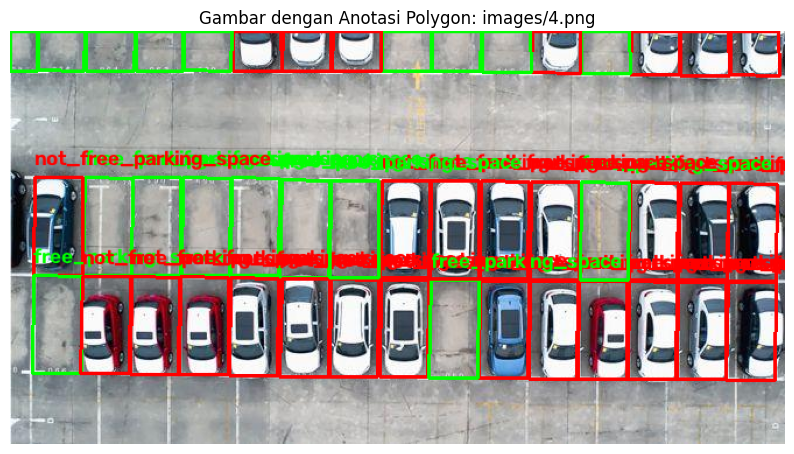

In [20]:
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
import numpy as np

# Pilih nama gambar untuk divisualisasikan
image_to_visualize = 'images/4.png' # Pilih gambar apapuun

# Membaca gambar
image_filename = os.path.basename(image_to_visualize)
image_path = os.path.join(CONFIG["IMAGES_DIR"], image_filename)
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Membaca anotasi XML
tree = ET.parse(CONFIG["XML_PATH"])
root = tree.getroot()

# Cari node gambar yang sesuai
image_node = None
for node in root.findall('image'):
    if node.get('name') == image_to_visualize:
        image_node = node
        break

if image_node is not None:
    # Buat salinan gambar untuk digambar anotasi
    img_with_annotations = img_rgb.copy()

    # Iterasi setiap polygon di gambar ini
    for polygon_node in image_node.findall('polygon'):
        points_str = polygon_node.get('points')
        label = polygon_node.get('label')

        # Parsing string points ke list of tuples (x, y)
        points = []
        for pair in points_str.split(';') :
            x, y = map(float, pair.split(','))
            points.append([int(x), int(y)]) # Menggunakan list of lists untuk cv2.polylines

        # Ubah points menjadi array numpy
        points_np = np.array(points, np.int32)
        points_np = points_np.reshape((-1, 1, 2)) # Reshape untuk cv2.polylines

        # Tentukan warna berdasarkan label
        color = (0, 255, 0) # Hijau untuk 'free_parking_space'
        if 'not_free_parking_space' in label:
            color = (255, 0, 0) # Merah untuk 'not_free_parking_space'
        elif 'partially_free_parking_space' in label:
            color = (255, 255, 0) # Kuning untuk 'partially_free_parking_space'

        # Gambar polygon
        cv2.polylines(img_with_annotations, [points_np], isClosed=True, color=color, thickness=2)

        # Tambahkan teks label (opsional)
        # Cari titik tengah polygon atau gunakan salah satu titik sudut untuk teks
        if points_np.size > 0:
            text_x, text_y = points_np[0][0][0], points_np[0][0][1] - 10 # Sedikit di atas titik pertama
            cv2.putText(img_with_annotations, label, (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    # Tampilkan gambar dengan anotasi
    plt.figure(figsize=(10, 8))
    plt.imshow(img_with_annotations)
    plt.title(f"Gambar dengan Anotasi Polygon: {image_to_visualize}")
    plt.axis('off')
    plt.show()
else:
    print(f"Node gambar untuk {image_to_visualize} tidak ditemukan dalam annotations.xml.")

#Split Data

Hasil :     
Kelas 0 -> Train: 191 | Val: 41 | Test: 41

Kelas 1 -> Train: 440 | Val: 94 | Test: 95

Dataset terstruktur siap digunakan di ./data/split.

In [21]:
import os
import shutil
from sklearn.model_selection import train_test_split

# 1. Konfigurasi direktori sumber dan target
PROCESSED_DIR = "./data/processed"
SPLIT_DIR = "./data/split"
CLASSES = ["0", "1"]

# 2. Proporsi partisi
TRAIN_RATIO = 0.70

print("Memulai pembagian partisi dataset...")

# Membuat struktur direktori train, val, dan test
for split in ["train", "val", "test"]:
    for cls in CLASSES:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls), exist_ok=True)

for cls in CLASSES:
    cls_dir = os.path.join(PROCESSED_DIR, cls)

    # Mengambil seluruh nama file di dalam folder kelas terkait
    files = [f for f in os.listdir(cls_dir) if os.path.isfile(os.path.join(cls_dir, f))]

    # Split Tahap 1: Pisahkan data Train (70%) dan Sisa data (30%)
    train_files, temp_files = train_test_split(files, train_size=TRAIN_RATIO, random_state=42)

    # Split Tahap 2: Bagi sisa data (30%) menjadi Validation (15%) dan Test (15%) secara rata
    val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

    # Fungsi bantuan untuk menyalin file ke folder tujuan
    def copy_files(file_list, split_name):
        for f in file_list:
            src = os.path.join(cls_dir, f)
            dst = os.path.join(SPLIT_DIR, split_name, cls, f)
            shutil.copy(src, dst)

    # Eksekusi penyalinan file
    copy_files(train_files, "train")
    copy_files(val_files, "val")
    copy_files(test_files, "test")

    print(f"Kelas {cls} -> Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

print(f"\nPartisi selesai! Dataset terstruktur siap digunakan di {SPLIT_DIR}.")

Memulai pembagian partisi dataset...
Kelas 0 -> Train: 191 | Val: 41 | Test: 41
Kelas 1 -> Train: 440 | Val: 94 | Test: 95

Partisi selesai! Dataset terstruktur siap digunakan di ./data/split.
